# Customer Churn Prediction Analysis

## Step 1: Understand the problem

### Problem Statement

Customers are very important because they generate income for the bank. Losing existing customers reduces the bank's revenue, and finding new customers usually costs much more than keeping current ones. Therefore, banks want to identify customers who are likely to leave before they actually do. By predicting customer churn early, the bank can take preventive actions, such as personalized offers and retention campaigns, to encourage customers to remain with the bank. This is the main objective of our Customer Churn Prediction Machine Learning project.

## Step 2: Importing Libraries


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## Step 3: Loading the Dataset

In [5]:
df = pd.read_csv("../data/Churn_Modelling.csv")

## Step 4: Performing Exploratory Data Analysis (EDA)

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          9999 non-null   object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [13]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            1
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

## Step 5: Data Cleaning (Observation)

The dataset was inspected for common data quality issues before preprocessing.

- No missing values were found.
- No duplicate records were found.
- The dataset is already clean and well-structured.
- Therefore, no major data cleaning was required before proceeding to the next phase.

## Step 6: Feature Engineering

In [16]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [17]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 7: Categorical Encoding

In [18]:
df.select_dtypes(include="object")

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female
...,...,...
9995,France,Male
9996,France,Male
9997,France,Female
9998,Germany,Male


In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Gender"] = label_encoder.fit_transform(df["Gender"])

In [20]:
df["Gender"].head(6) 

0    0
1    0
2    0
3    0
4    0
5    1
Name: Gender, dtype: int64

In [21]:
drop_first=True

In [22]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [23]:
df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [24]:
df.dtypes

CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany       bool
Geography_Spain         bool
dtype: object

In [25]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(8)
memory usage: 800.9 KB


In [27]:
df.head().T

,0,1,2,3,4
CreditScore,619,608,502,699,850
Gender,0,0,0,0,0
Age,42,41,42,39,43
Tenure,2,1,8,1,2
Balance,0.0,83807.86,159660.8,0.0,125510.82
NumOfProducts,1,1,3,2,1
HasCrCard,1,0,1,0,1
IsActiveMember,1,1,0,0,1
EstimatedSalary,101348.88,112542.58,113931.57,93826.63,79084.1
Exited,1,0,1,0,0


# Step 8: Feature Scaling

In [28]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [29]:
numerical_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

In [33]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,-0.326221,0,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,False,False
1,-0.440036,0,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,False,True
2,-1.536794,0,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,False,False
3,0.501521,0,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,False,False
4,2.063884,0,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,False,True


# Step 9: Feature Selection

In [34]:
correlation_matrix = df.corr()
correlation_matrix

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


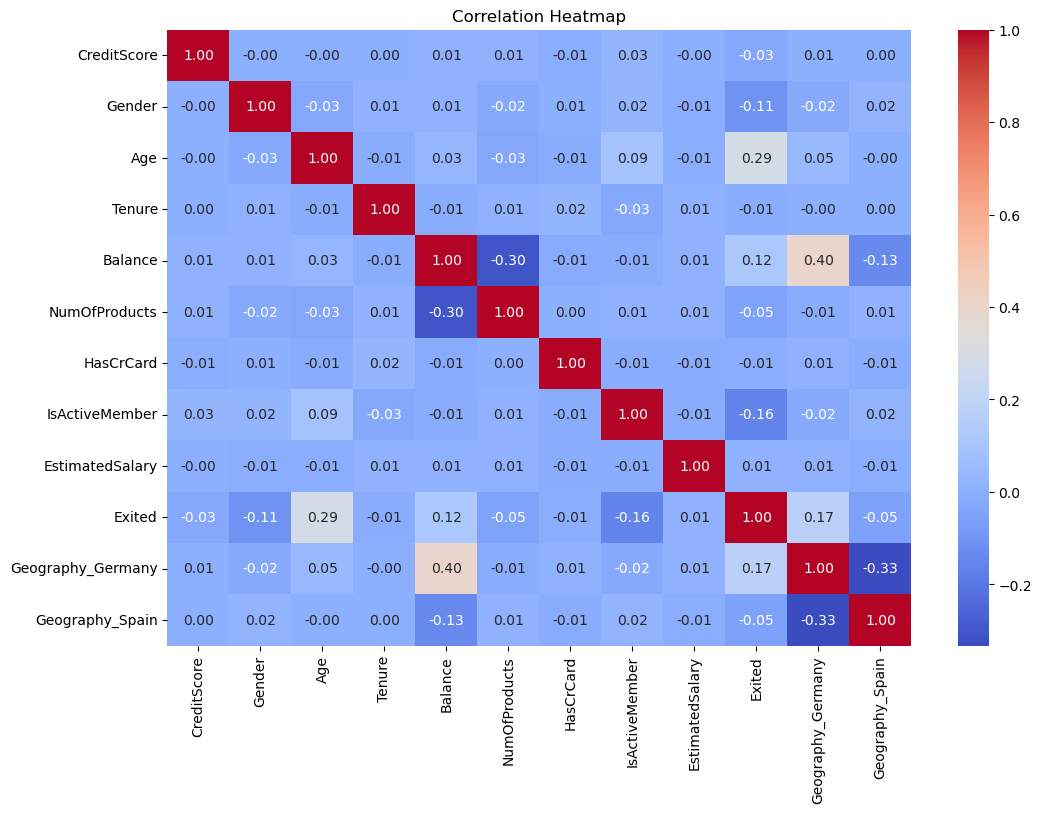

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [36]:
correlation_with_target = df.corr()["Exited"].sort_values(ascending=False)
correlation_with_target

Exited               1.000000
Age                  0.285323
Geography_Germany    0.173488
Balance              0.118533
EstimatedSalary      0.012097
HasCrCard           -0.007138
Tenure              -0.014001
CreditScore         -0.027094
NumOfProducts       -0.047820
Geography_Spain     -0.052667
Gender              -0.106512
IsActiveMember      -0.156128
Name: Exited, dtype: float64

# Step 10: Train-Test Split

In [37]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (8000, 11)
Testing Features: (2000, 11)
Training Labels: (8000,)
Testing Labels: (2000,)


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Step 11: Model Building

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
model = LogisticRegression(random_state=42)

In [44]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
y_pred = model.predict(X_test)

In [46]:
y_prob = model.predict_proba(X_test)

# Step 12: Evaluate Logistic Regression

In [47]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [48]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.808


In [49]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1540   53]
 [ 331   76]]


In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [51]:
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.774824130756334


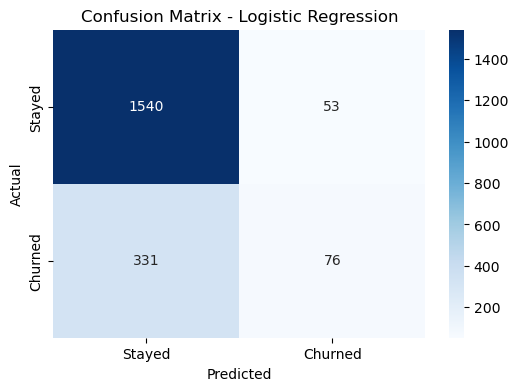

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# Step 13: Build Ensemble Models

In [53]:
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

In [54]:
random_forest = RandomForestClassifier(random_state=42)
adaboost = AdaBoostClassifier(random_state=42)
gradient_boost = GradientBoostingClassifier(random_state=42)

In [55]:
random_forest.fit(X_train, y_train)
adaboost.fit(X_train, y_train)
gradient_boost.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [56]:
rf_pred = random_forest.predict(X_test)
ada_pred = adaboost.predict(X_test)
gb_pred = gradient_boost.predict(X_test)

In [57]:
rf_prob = random_forest.predict_proba(X_test)[:,1]
ada_prob = adaboost.predict_proba(X_test)[:,1]
gb_prob = gradient_boost.predict_proba(X_test)[:,1]

# Step 14: Evaluate Ensemble Models

In [58]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8615


In [59]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[1538   55]
 [ 222  185]]


In [60]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [61]:
print("ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.8542618118889306


## AdaBoost

In [62]:
print("AdaBoost Accuracy:",
      accuracy_score(y_test, ada_pred))
print(confusion_matrix(y_test, ada_pred))
print(classification_report(y_test, ada_pred))
print("ROC-AUC:",
      roc_auc_score(y_test, ada_prob))

AdaBoost Accuracy: 0.86
[[1536   57]
 [ 223  184]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.76      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC: 0.8481123650615177


## Gradient Boosting

In [63]:
print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))
print("ROC-AUC:",
      roc_auc_score(y_test, gb_prob))

Gradient Boosting Accuracy: 0.87
[[1541   52]
 [ 208  199]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

ROC-AUC: 0.8708307691358538


## Step 15: Compare All Models

In [64]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, ada_prob),
        roc_auc_score(y_test, gb_prob)
    ]
}

In [65]:
comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.8080,0.774824
1,Random Forest,0.8615,0.854262
2,AdaBoost,0.8600,0.848112
3,Gradient Boosting,0.8700,0.870831


In [66]:
best_model = gradient_boost

print("Best Model Selected:")
print(best_model)

Best Model Selected:
GradientBoostingClassifier(random_state=42)


In [67]:
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy,ROC-AUC
3,Gradient Boosting,0.8700,0.870831
1,Random Forest,0.8615,0.854262
2,AdaBoost,0.8600,0.848112
0,Logistic Regression,0.8080,0.774824


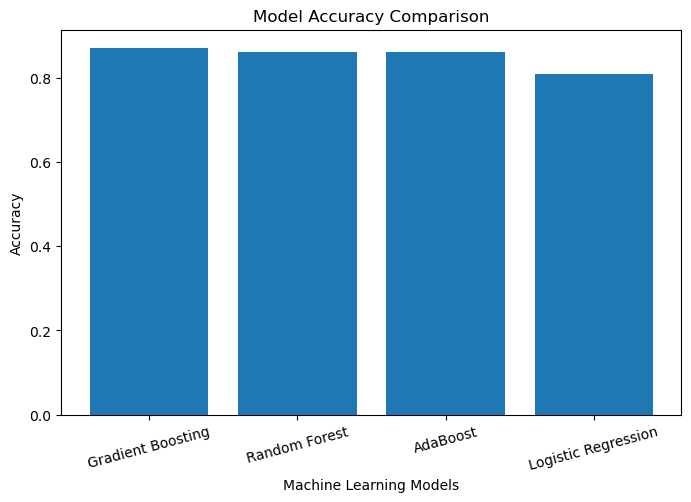

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

# Step 16: Interpret Feature Importance 

In [69]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance

,Feature,Importance
0,CreditScore,0.144612
1,Gender,0.018053
2,Age,0.239730
3,Tenure,0.081985
4,Balance,0.143798
5,NumOfProducts,0.123917
6,HasCrCard,0.018697
7,IsActiveMember,0.041726
8,EstimatedSalary,0.144951
9,Geography_Germany,0.028757


In [70]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Age,0.239730
8,EstimatedSalary,0.144951
0,CreditScore,0.144612
4,Balance,0.143798
5,NumOfProducts,0.123917
3,Tenure,0.081985
7,IsActiveMember,0.041726
9,Geography_Germany,0.028757
6,HasCrCard,0.018697
1,Gender,0.018053


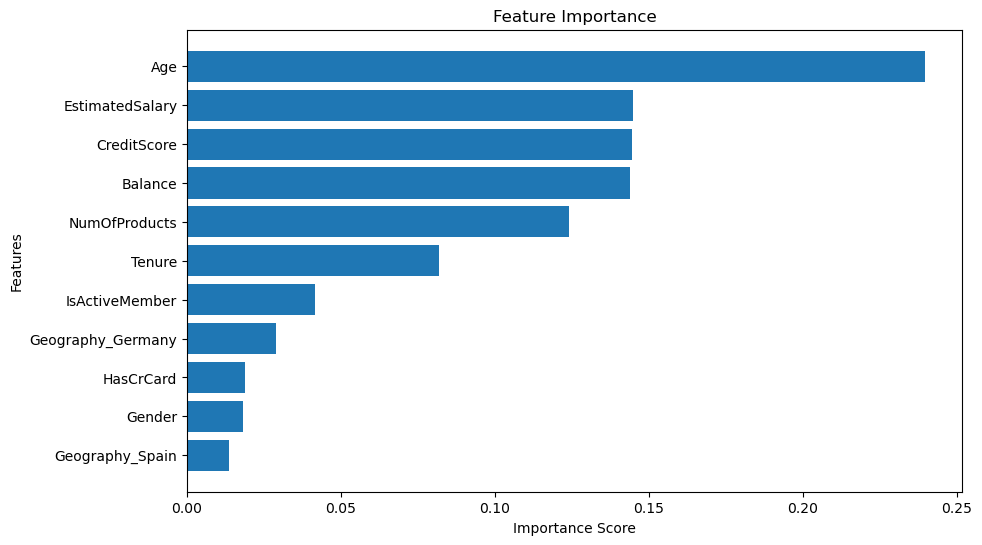

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

# Step 17: Generate Business Insights

- The machine learning model successfully identified customers who are at risk of churn.

- Age was one of the most influential features, suggesting that customer retention strategies may need to be tailored for different age groups.

- Active members were less likely to churn, indicating that increasing customer engagement could improve retention.

- Customers with higher account balances showed a greater tendency to churn, making them a priority group for personalized retention campaigns.

- Customers with lower credit scores may require additional financial support or targeted banking products.

- The best-performing machine learning model can be integrated into the bank's customer relationship management (CRM) system to identify at-risk customers before they leave.

# Step 18: Final Report

## Project Summary

This project focused on predicting customer churn in a banking environment using supervised machine learning techniques.

The project began with data exploration and cleaning, followed by feature engineering, categorical variable encoding, feature scaling, feature selection, and train-test splitting.

Multiple classification models were developed, including Logistic Regression, Random Forest, AdaBoost, and Gradient Boosting.

Each model was evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC Score.

The best-performing model achieved the highest predictive performance and was selected for customer churn prediction.

Feature importance analysis revealed the most influential customer characteristics affecting churn.

Finally, business insights were generated to help the bank improve customer retention through proactive intervention and targeted marketing campaigns.

In [72]:
import joblib
joblib.dump(best_model, "../models/best_model.pkl")
print("Best model saved successfully.")

Best model saved successfully.


In [81]:
import os
os.listdir()

['Customer_Churn_Prediction.ipynb']

In [73]:
joblib.dump(scaler, "../models/scaler.pkl")
print("Scaler saved successfully.")

Scaler saved successfully.


In [74]:
# ============================================================
# Verify Saved Files
# ============================================================

import joblib

model = joblib.load("../models/best_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

print("Model Type:")
print(type(model))

print("\nScaler Type:")
print(type(scaler))

print("\nScaler Features:")
print(scaler.feature_names_in_)

Model Type:
<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>

Scaler Type:
<class 'sklearn.preprocessing._data.StandardScaler'>

Scaler Features:
['CreditScore' 'Age' 'Tenure' 'Balance' 'NumOfProducts' 'EstimatedSalary']
